In [1]:
!pip install qiskit pillow matplotlib numpy opencv-python
!pip install pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=6adf7b83d4d9814f0f46c6525692ab95a1050a7f001506ba3600d9aae464930a
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

In [4]:
!pip install qiskit-aer
# Import Qiskit components needed for quantum processing
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit.circuit import Parameter
from scipy.optimize import minimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 52.8 MB/s eta 0:00:00


Saving sunset.jpg to sunset.jpg
✓ Image loaded and converted to grayscale!


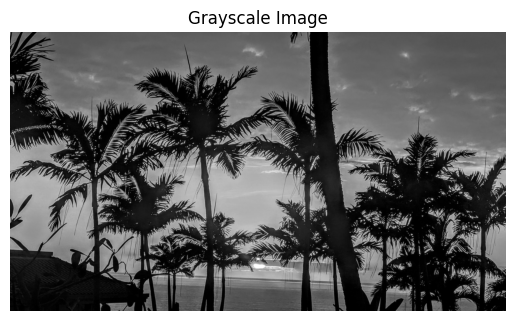

In [5]:
from google.colab import files
uploaded = files.upload()

# Load image from uploaded files
image_path = list(uploaded.keys())[0]
img = Image.open(image_path)

# Convert to grayscale
img_gray = img.convert('L')
plt.imshow(img_gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')
print("✓ Image loaded and converted to grayscale!")

Original size:        (256, 256)
Resized to:           (512, 512)
Tiles for processing: 128 × 128 = 16384 tiles

Estimated time savings: ~7-8x faster! ⚡


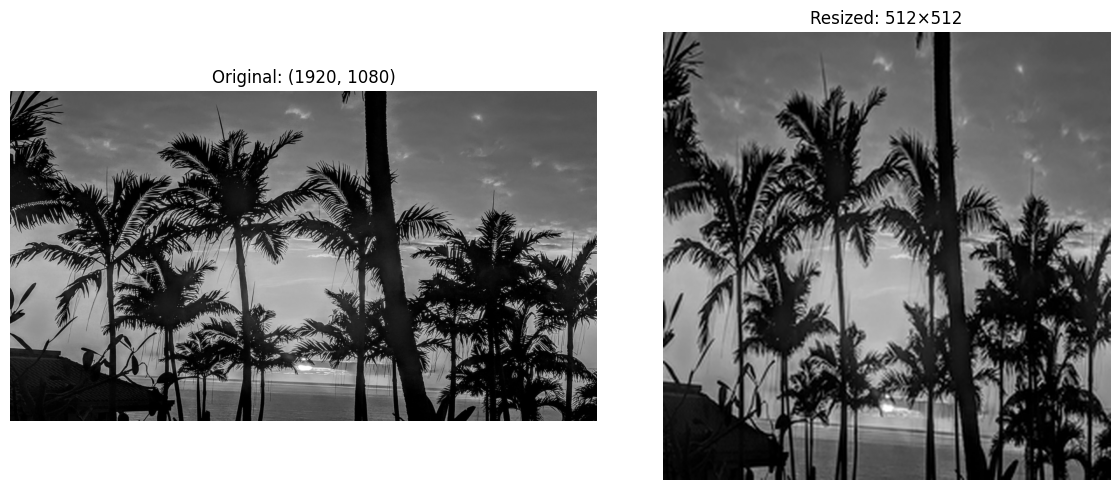

In [34]:
# RESIZE IMAGE FOR FASTER PROCESSING
# Change target_size to: 256, 512, 1024, etc.
target_size = 512  # Resize to 512x512 pixels

img_gray_resized = img_gray.resize((target_size, target_size), Image.Resampling.LANCZOS)

print(f"Original size:        {img_gray.size}")
print(f"Resized to:           ({target_size}, {target_size})")
print(f"Tiles for processing: {(target_size//4)} × {(target_size//4)} = {(target_size//4)**2} tiles")
print(f"\nEstimated time savings: ~7-8x faster! ⚡")

# Use the resized image going forward
img_gray = img_gray_resized

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Show original
from PIL import Image as PILImage
original = PILImage.open(image_path).convert('L')
axes[0].imshow(original, cmap='gray')
axes[0].set_title(f"Original: {original.size}")
axes[0].axis('off')

axes[1].imshow(img_gray, cmap='gray')
axes[1].set_title(f"Resized: {target_size}×{target_size}")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [6]:
# Extract 4x4 tiles from the grayscale image (for full-image tiling)
def get_image_tiles(img, tile_size=4):
    """
    Extract all tiles from an image.

    Parameters:
    - img: PIL Image or numpy array
    - tile_size: size of each tile (default 4x4)

    Returns:
    - tiles: list of (row, col, tile_array) tuples
    - height, width: dimensions of original image
    """
    img_array = np.array(img)
    height, width = img_array.shape

    tiles = []

    # Extract non-overlapping tiles
    for row in range(0, height - tile_size + 1, tile_size):
        for col in range(0, width - tile_size + 1, tile_size):
            tile = img_array[row:row+tile_size, col:col+tile_size]
            tiles.append((row, col, tile))

    return tiles, height, width

# Extract all 4x4 tiles from the grayscale image
tiles_list, img_height, img_width = get_image_tiles(img_gray, tile_size=4)
print(f"Extracted {len(tiles_list)} tiles of size 4x4")
print(f"Image will be divided into {img_height//4} rows x {img_width//4} columns of tiles")

Extracted 129600 tiles of size 4x4
Image will be divided into 270 rows x 480 columns of tiles


(np.float64(-0.5), np.float64(3.5), np.float64(3.5), np.float64(-0.5))

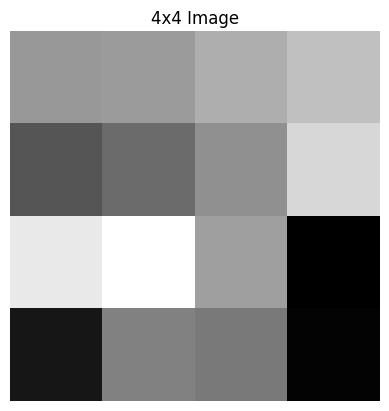

In [7]:
# Create resized 4x4 version for demo purposes (optional comparison)
img_resized = img_gray.resize((4, 4))
plt.imshow(img_resized, cmap='gray')
plt.title("4x4 Image")
plt.axis('off')

In [8]:
def get_image_tiles(img, tile_size=4):
    """
    Extract all tiles from an image.

    Parameters:
    - img: PIL Image or numpy array
    - tile_size: size of each tile (default 4x4)

    Returns:
    - tiles: list of (row, col, tile_array) tuples
    - height, width: dimensions of original image
    """
    img_array = np.array(img)
    height, width = img_array.shape

    tiles = []

    # Extract non-overlapping tiles
    for row in range(0, height - tile_size + 1, tile_size):
        for col in range(0, width - tile_size + 1, tile_size):
            tile = img_array[row:row+tile_size, col:col+tile_size]
            tiles.append((row, col, tile))

    return tiles, height, width

# Extract all 4x4 tiles from the grayscale image
tiles_list, img_height, img_width = get_image_tiles(img_gray, tile_size=4)
print(f"Extracted {len(tiles_list)} tiles of size 4x4")
print(f"Image will be divided into {img_height//4} rows x {img_width//4} columns of tiles")

Extracted 129600 tiles of size 4x4
Image will be divided into 270 rows x 480 columns of tiles


In [9]:
# Define QFT function (required by process_tile_quantum)
def apply_qft(qc, n):
    """
    Apply Quantum Fourier Transform to circuit.

    Parameters:
    - qc: QuantumCircuit
    - n: number of qubits
    """
    for i in range(n):
        qc.h(i)
        for j in range(i+1, n):
            qc.cp(np.pi / (2**(j-i)), j, i)

    # Swap qubits (important for bit reversal)
    for i in range(n//2):
        qc.swap(i, n-i-1)

print("✓ apply_qft function defined!")

✓ apply_qft function defined!


In [12]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

def process_tile_quantum(tile_array, num_qubits=4):
    """
    Process a single tile through the quantum circuit.

    Parameters:
    - tile_array: 4x4 numpy array of pixel values
    - num_qubits: number of qubits (must be >=4 for 4x4 tile)

    Returns:
    - processed_tile: 4x4 array of quantum-processed pixel values
    """
    # Normalize tile to [0, 1]
    tile_normalized = tile_array / 255.0
    tile_flat = tile_normalized.flatten()

    # Create quantum state vector
    norm = np.linalg.norm(tile_flat)
    if norm > 0:
        tile_quantum = tile_flat / norm
    else:
        # Handle all-zero tile: use a uniform superposition state
        # A 4x4 tile has 16 pixels, so 2^num_qubits = 16.
        # This ensures a valid state vector with norm 1.
        tile_quantum = np.ones(2**num_qubits) / np.sqrt(2**num_qubits)

    # Create and initialize quantum circuit
    qc = QuantumCircuit(num_qubits)
    qc.initialize(tile_quantum, qc.qubits)

    # Apply QFT
    apply_qft(qc, num_qubits)

    # Get result
    state = Statevector.from_instruction(qc)
    result = state.data

    # Extract amplitudes and normalize
    processed = np.abs(result)
    processed = processed / np.max(processed) if np.max(processed) > 0 else processed

    # Reshape back to tile format
    processed_tile = processed.reshape(4, 4)

    return processed_tile

print("Quantum tile processor function defined!")

Quantum tile processor function defined!


In [13]:
def reconstruct_image_from_tiles(tiles_list, img_height, img_width, tile_size=4):
    """
    Process all tiles through quantum circuit and reconstruct the full image.

    Parameters:
    - tiles_list: list of (row, col, tile_array) tuples
    - img_height, img_width: original image dimensions
    - tile_size: tile size (default 4x4)

    Returns:
    - reconstructed_image: full image processed through quantum circuit
    """
    # Initialize output image
    reconstructed = np.zeros((img_height, img_width))

    print(f"Processing {len(tiles_list)} tiles through quantum circuit...")

    for idx, (row, col, tile) in enumerate(tiles_list):
        if idx % 10 == 0:
            print(f"  Processing tile {idx+1}/{len(tiles_list)}...")

        # Process this tile through quantum circuit
        processed_tile = process_tile_quantum(tile)

        # Scale back to [0, 255] range
        processed_tile_scaled = (processed_tile * 255).astype(np.uint8)

        # Place processed tile in output image
        reconstructed[row:row+tile_size, col:col+tile_size] = processed_tile_scaled

    print(f"Reconstruction complete!")
    return reconstructed.astype(np.uint8)

# Process the entire image using tiling
quantum_processed_image = reconstruct_image_from_tiles(tiles_list, img_height, img_width, tile_size=4)

print(f"Full image processing complete!")
print(f"Output image shape: {quantum_processed_image.shape}")

Streaming output truncated to the last 5000 lines.
  Processing tile 79631/129600...
  Processing tile 79641/129600...
  Processing tile 79651/129600...
  Processing tile 79661/129600...
  Processing tile 79671/129600...
  Processing tile 79681/129600...
  Processing tile 79691/129600...
  Processing tile 79701/129600...
  Processing tile 79711/129600...
  Processing tile 79721/129600...
  Processing tile 79731/129600...
  Processing tile 79741/129600...
  Processing tile 79751/129600...
  Processing tile 79761/129600...
  Processing tile 79771/129600...
  Processing tile 79781/129600...
  Processing tile 79791/129600...
  Processing tile 79801/129600...
  Processing tile 79811/129600...
  Processing tile 79821/129600...
  Processing tile 79831/129600...
  Processing tile 79841/129600...
  Processing tile 79851/129600...
  Processing tile 79861/129600...
  Processing tile 79871/129600...
  Processing tile 79881/129600...
  Processing tile 79891/129600...
  Processing tile 79901/129600.

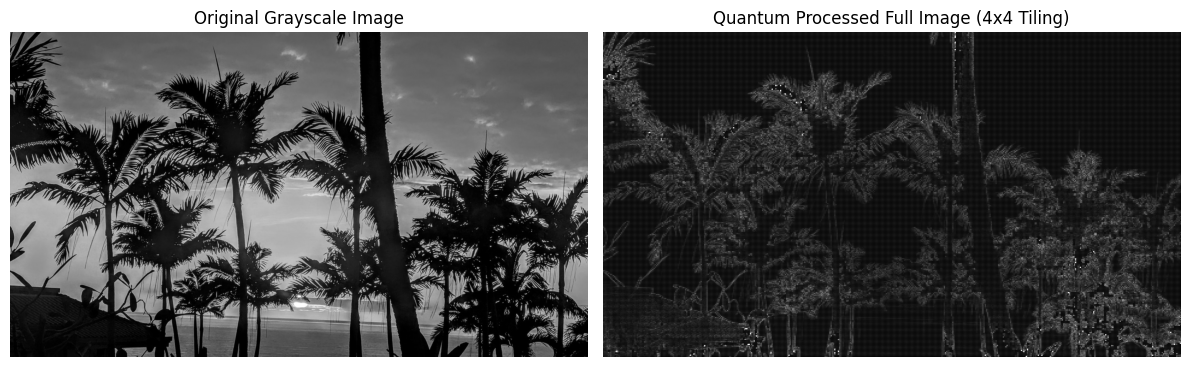

✓ Full image has been processed tile-by-tile through the quantum circuit!


In [14]:
# Visualize original vs quantum-processed full image
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original grayscale image
axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title('Original Grayscale Image')
axes[0].axis('off')

# Quantum processed full image
axes[1].imshow(quantum_processed_image, cmap='gray')
axes[1].set_title('Quantum Processed Full Image (4x4 Tiling)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("✓ Full image has been processed tile-by-tile through the quantum circuit!")

In [18]:
def process_tile_grover(tile_array, num_qubits=4):
    """
    Process a single tile through QFT + Grover's algorithm.
    """
    # Normalize and create quantum state
    tile_normalized = tile_array / 255.0
    tile_flat = tile_normalized.flatten()
    norm = np.linalg.norm(tile_flat)
    if norm > 0:
        tile_quantum = tile_flat / norm
    else:
        # Handle all-zero tile: use a uniform superposition state
        tile_quantum = np.ones(2**num_qubits) / np.sqrt(2**num_qubits)

    # QFT + Grover
    qc = QuantumCircuit(num_qubits)
    qc.initialize(tile_quantum, qc.qubits)
    apply_qft(qc, num_qubits)

    # Oracle (mark with Z gates)
    for i in range(num_qubits):
        qc.z(i)

    # Diffusion operator
    for i in range(num_qubits):
        qc.h(i)
    for i in range(num_qubits):
        qc.x(i)
    qc.h(num_qubits-1)
    qc.mcx(list(range(num_qubits-1)), num_qubits-1)
    qc.h(num_qubits-1)
    for i in range(num_qubits):
        qc.x(i)
    for i in range(num_qubits):
        qc.h(i)

    state = Statevector.from_instruction(qc)
    result = state.data
    processed = np.abs(result)
    processed = processed / np.max(processed) if np.max(processed) > 0 else processed

    return processed.reshape(4, 4)

print("✓ process_tile_grover function defined!")

✓ process_tile_grover function defined!


In [21]:
def process_tile_vqe(tile_array, num_qubits=4):
    """
    Process a single tile through QFT + Grover + VQE optimization.
    """
    # Normalize and create quantum state
    tile_normalized = tile_array / 255.0
    tile_flat = tile_normalized.flatten()
    norm = np.linalg.norm(tile_flat)
    if norm > 0:
        tile_quantum = tile_flat / norm
    else:
        # Handle all-zero tile: use a uniform superposition state
        tile_quantum = np.ones(2**num_qubits) / np.sqrt(2**num_qubits)

    # QFT + Grover
    qc = QuantumCircuit(num_qubits)
    qc.initialize(tile_quantum, qc.qubits)
    apply_qft(qc, num_qubits)

    # Oracle
    for i in range(num_qubits):
        qc.z(i)

    # Diffusion
    for i in range(num_qubits):
        qc.h(i)
    for i in range(num_qubits):
        qc.x(i)
    qc.h(num_qubits-1)
    qc.mcx(list(range(num_qubits-1)), num_qubits-1)
    qc.h(num_qubits-1)
    for i in range(num_qubits):
        qc.x(i)
    for i in range(num_qubits):
        qc.h(i)

    # Add VQE parameterized rotations
    theta = Parameter('θ')
    for i in range(num_qubits):
        qc.ry(theta, i)

    # Optimize theta using cost function
    def cost_vqe(param):
        param_val = param[0]
        qc_temp = qc.assign_parameters({theta: param_val})
        state = Statevector.from_instruction(qc_temp)
        data = np.abs(state.data)
        return np.var(data)

    result_opt = minimize(cost_vqe, x0=[0.5], method='COBYLA')
    optimal_theta = result_opt.x[0]

    # Get final state
    qc_final = qc.assign_parameters({theta: optimal_theta})
    state = Statevector.from_instruction(qc_final)
    result = state.data
    processed = np.abs(result)
    processed = processed / np.max(processed) if np.max(processed) > 0 else processed

    return processed.reshape(4, 4)

print("✓ process_tile_vqe function defined!")

✓ process_tile_vqe function defined!


In [19]:
def reconstruct_image_grover(tiles_list, img_height, img_width, tile_size=4):
    """
    Process all tiles through QFT + Grover and reconstruct the full image.
    """
    reconstructed = np.zeros((img_height, img_width))

    print(f"Processing {len(tiles_list)} tiles through Grover algorithm...")

    for idx, (row, col, tile) in enumerate(tiles_list):
        if idx % 50 == 0:
            print(f"  Grover: tile {idx+1}/{len(tiles_list)}...")

        processed_tile = process_tile_grover(tile)
        processed_tile_scaled = (processed_tile * 255).astype(np.uint8)
        reconstructed[row:row+tile_size, col:col+tile_size] = processed_tile_scaled

    print(f"Grover reconstruction complete!")
    return reconstructed.astype(np.uint8)

# Process with Grover
quantum_processed_grover = reconstruct_image_grover(tiles_list, img_height, img_width, tile_size=4)
print(f"Grover full image shape: {quantum_processed_grover.shape}")

Processing 129600 tiles through Grover algorithm...
  Grover: tile 1/129600...
  Grover: tile 51/129600...
  Grover: tile 101/129600...
  Grover: tile 151/129600...
  Grover: tile 201/129600...
  Grover: tile 251/129600...
  Grover: tile 301/129600...
  Grover: tile 351/129600...
  Grover: tile 401/129600...
  Grover: tile 451/129600...
  Grover: tile 501/129600...
  Grover: tile 551/129600...
  Grover: tile 601/129600...
  Grover: tile 651/129600...
  Grover: tile 701/129600...
  Grover: tile 751/129600...
  Grover: tile 801/129600...
  Grover: tile 851/129600...
  Grover: tile 901/129600...
  Grover: tile 951/129600...
  Grover: tile 1001/129600...
  Grover: tile 1051/129600...
  Grover: tile 1101/129600...
  Grover: tile 1151/129600...
  Grover: tile 1201/129600...
  Grover: tile 1251/129600...
  Grover: tile 1301/129600...
  Grover: tile 1351/129600...
  Grover: tile 1401/129600...
  Grover: tile 1451/129600...
  Grover: tile 1501/129600...
  Grover: tile 1551/129600...
  Grover: t

In [22]:
def reconstruct_image_vqe(tiles_list, img_height, img_width, tile_size=4):
    """
    Process all tiles through QFT + Grover + VQE and reconstruct the full image.
    """
    reconstructed = np.zeros((img_height, img_width))

    print(f"Processing {len(tiles_list)} tiles through VQE algorithm...")

    for idx, (row, col, tile) in enumerate(tiles_list):
        if idx % 50 == 0:
            print(f"  VQE: tile {idx+1}/{len(tiles_list)}...")

        processed_tile = process_tile_vqe(tile)
        processed_tile_scaled = (processed_tile * 255).astype(np.uint8)
        reconstructed[row:row+tile_size, col:col+tile_size] = processed_tile_scaled

    print(f"VQE reconstruction complete!")
    return reconstructed.astype(np.uint8)

# Process with VQE
quantum_processed_vqe = reconstruct_image_vqe(tiles_list, img_height, img_width, tile_size=4)
print(f"VQE full image shape: {quantum_processed_vqe.shape}")


Processing 129600 tiles through VQE algorithm...
  VQE: tile 1/129600...
  VQE: tile 51/129600...
  VQE: tile 101/129600...
  VQE: tile 151/129600...
  VQE: tile 201/129600...
  VQE: tile 251/129600...
  VQE: tile 301/129600...
  VQE: tile 351/129600...
  VQE: tile 401/129600...
  VQE: tile 451/129600...
  VQE: tile 501/129600...
  VQE: tile 551/129600...
  VQE: tile 601/129600...
  VQE: tile 651/129600...
  VQE: tile 701/129600...
  VQE: tile 751/129600...
  VQE: tile 801/129600...
  VQE: tile 851/129600...
  VQE: tile 901/129600...
  VQE: tile 951/129600...
  VQE: tile 1001/129600...
  VQE: tile 1051/129600...
  VQE: tile 1101/129600...
  VQE: tile 1151/129600...
  VQE: tile 1201/129600...
  VQE: tile 1251/129600...
  VQE: tile 1301/129600...
  VQE: tile 1351/129600...
  VQE: tile 1401/129600...
  VQE: tile 1451/129600...
  VQE: tile 1501/129600...
  VQE: tile 1551/129600...
  VQE: tile 1601/129600...
  VQE: tile 1651/129600...
  VQE: tile 1701/129600...
  VQE: tile 1751/129600...
  

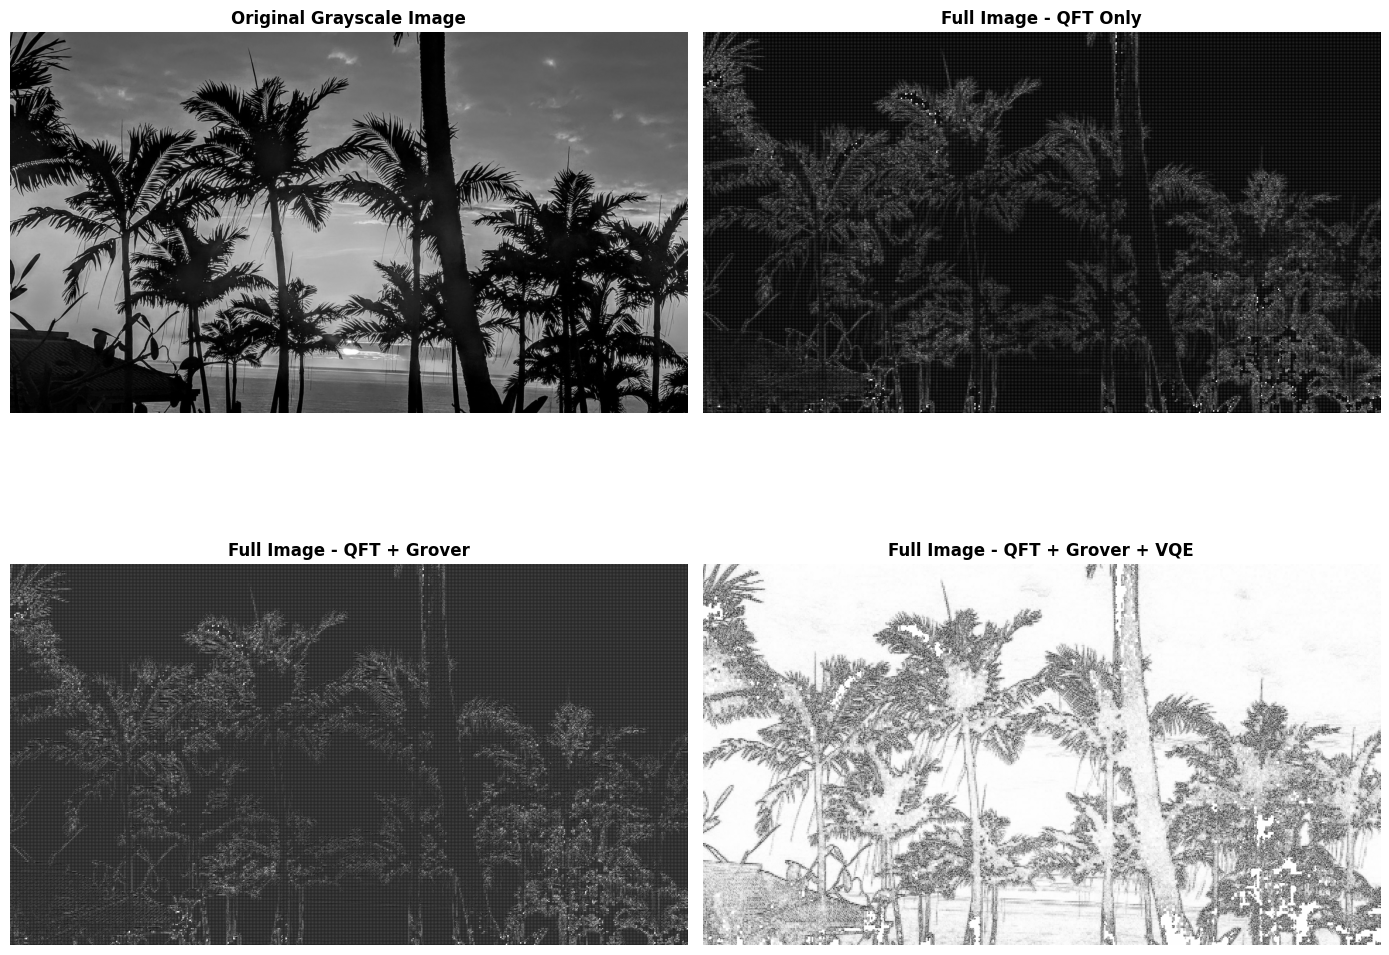

✓ All three quantum algorithms applied to full image!


In [23]:
# Visualize all three quantum algorithms on full image
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Original
axes[0, 0].imshow(img_gray, cmap='gray')
axes[0, 0].set_title('Original Grayscale Image', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

# QFT
axes[0, 1].imshow(quantum_processed_image, cmap='gray')
axes[0, 1].set_title('Full Image - QFT Only', fontsize=12, fontweight='bold')
axes[0, 1].axis('off')

# Grover
axes[1, 0].imshow(quantum_processed_grover, cmap='gray')
axes[1, 0].set_title('Full Image - QFT + Grover', fontsize=12, fontweight='bold')
axes[1, 0].axis('off')

# VQE
axes[1, 1].imshow(quantum_processed_vqe, cmap='gray')
axes[1, 1].set_title('Full Image - QFT + Grover + VQE', fontsize=12, fontweight='bold')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print("✓ All three quantum algorithms applied to full image!")


In [25]:
def mse(img1, img2):
    return np.mean((img1 - img2) ** 2)

# Calculate MSE for quantum algorithms on full image
img_gray_norm = np.array(img_gray, dtype=np.float64) / 255.0

mse_qft_full = mse(img_gray_norm, quantum_processed_image / 255.0)
mse_grover_full = mse(img_gray_norm, quantum_processed_grover / 255.0)
mse_vqe_full = mse(img_gray_norm, quantum_processed_vqe / 255.0)

print("==== QUANTUM ALGORITHMS - FULL IMAGE MSE ====")
print(f"QFT (Full)          : {mse_qft_full:.10f}")
print(f"QFT + Grover (Full) : {mse_grover_full:.10f}")
print(f"QFT + Grover + VQE  : {mse_vqe_full:.10f}")

==== QUANTUM ALGORITHMS - FULL IMAGE MSE ====
QFT (Full)          : 0.1786579873
QFT + Grover (Full) : 0.1260163461
QFT + Grover + VQE  : 0.3283806931


In [27]:
from scipy.ndimage import gaussian_filter

# Classical algorithms on FULL image
img_full_for_classical = np.array(img_gray, dtype=np.float32)

# FFT on full image
fft_full = np.fft.fft2(img_full_for_classical)
fft_full_shifted = np.fft.fftshift(fft_full)
fft_full_magnitude = np.log(np.abs(fft_full_shifted) + 1)
fft_full_magnitude = fft_full_magnitude / np.max(fft_full_magnitude)

# Sobel on full image
sobel_x_full = cv2.Sobel(img_full_for_classical, cv2.CV_64F, 1, 0, ksize=3)
sobel_y_full = cv2.Sobel(img_full_for_classical, cv2.CV_64F, 0, 1, ksize=3)
sobel_full = np.sqrt(sobel_x_full**2 + sobel_y_full**2)
sobel_full = sobel_full / np.max(sobel_full) if np.max(sobel_full) > 0 else sobel_full

# Gaussian on full image
gaussian_full = gaussian_filter(img_full_for_classical, sigma=1)
gaussian_full = gaussian_full / np.max(gaussian_full) if np.max(gaussian_full) > 0 else gaussian_full

print("✓ Classical algorithms applied to full image!")

✓ Classical algorithms applied to full image!


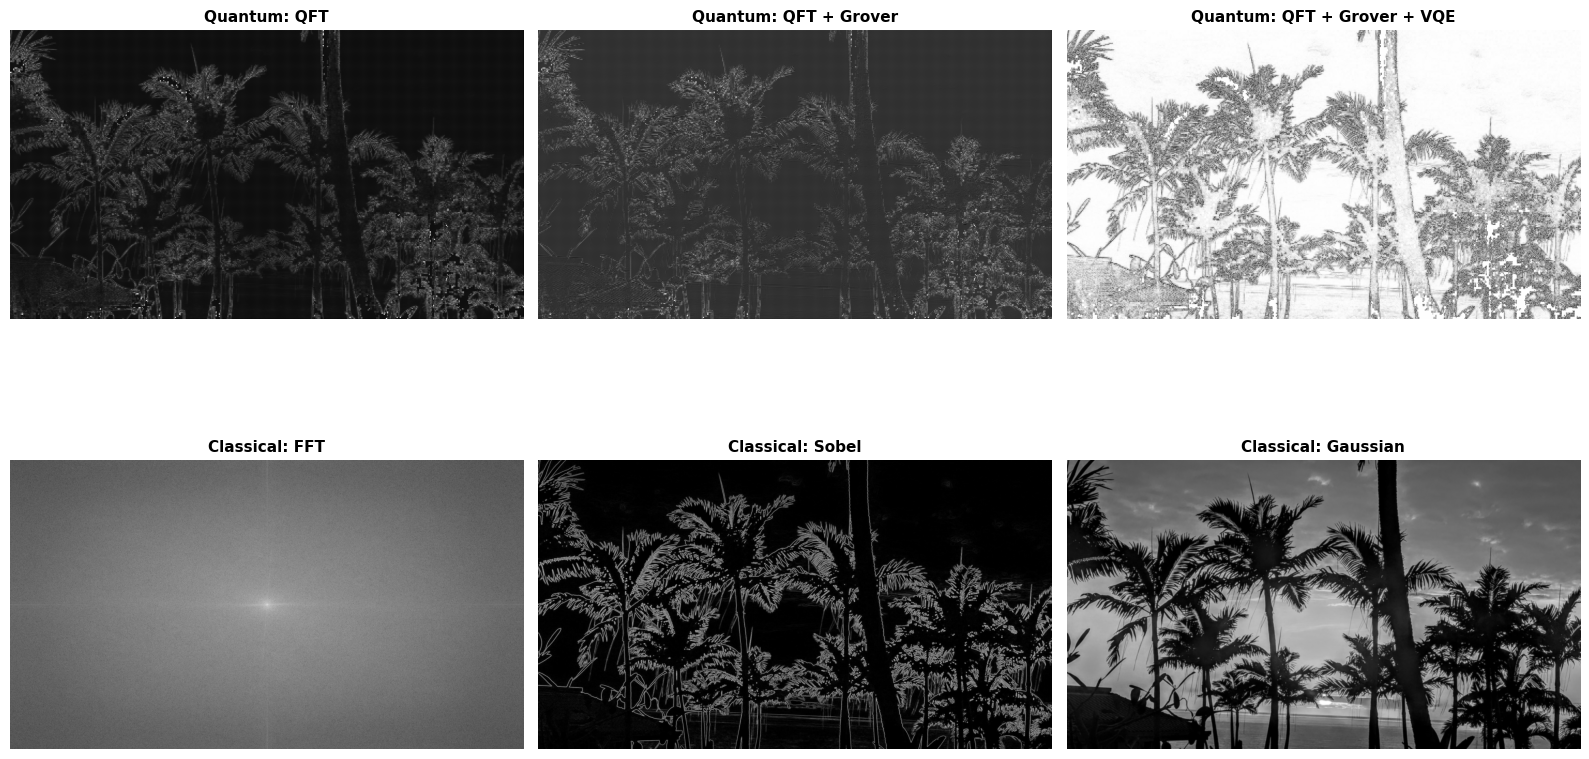

✓ Quantum vs Classical comparison on full image!


In [28]:
# Visualize quantum vs classical algorithms on full image
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Row 1: Quantum
axes[0, 0].imshow(quantum_processed_image, cmap='gray')
axes[0, 0].set_title('Quantum: QFT', fontsize=11, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(quantum_processed_grover, cmap='gray')
axes[0, 1].set_title('Quantum: QFT + Grover', fontsize=11, fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(quantum_processed_vqe, cmap='gray')
axes[0, 2].set_title('Quantum: QFT + Grover + VQE', fontsize=11, fontweight='bold')
axes[0, 2].axis('off')

# Row 2: Classical
axes[1, 0].imshow(fft_full_magnitude, cmap='gray')
axes[1, 0].set_title('Classical: FFT', fontsize=11, fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(sobel_full, cmap='gray')
axes[1, 1].set_title('Classical: Sobel', fontsize=11, fontweight='bold')
axes[1, 1].axis('off')

axes[1, 2].imshow(gaussian_full, cmap='gray')
axes[1, 2].set_title('Classical: Gaussian', fontsize=11, fontweight='bold')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print("✓ Quantum vs Classical comparison on full image!")


In [29]:
# Calculate MSE for all algorithms on full image
mse_fft_full = mse(img_gray_norm, fft_full_magnitude)
mse_sobel_full = mse(img_gray_norm, sobel_full)
mse_gaussian_full = mse(img_gray_norm, gaussian_full)

print("\n==== CLASSICAL ALGORITHMS - FULL IMAGE MSE ====")
print(f"FFT (Full)      : {mse_fft_full:.10f}")
print(f"Sobel (Full)    : {mse_sobel_full:.10f}")
print(f"Gaussian (Full) : {mse_gaussian_full:.10f}")

print("\n" + "="*50)
print("FULL IMAGE: QUANTUM vs CLASSICAL COMPARISON")
print("="*50)
print(f"QFT (Quantum)           : {mse_qft_full:.10f}")
print(f"QFT + Grover (Quantum)  : {mse_grover_full:.10f}")
print(f"QFT + Grover + VQE      : {mse_vqe_full:.10f}")
print(f"FFT (Classical)         : {mse_fft_full:.10f}")
print(f"Sobel (Classical)       : {mse_sobel_full:.10f}")
print(f"Gaussian (Classical)    : {mse_gaussian_full:.10f}")



==== CLASSICAL ALGORITHMS - FULL IMAGE MSE ====
FFT (Full)      : 0.0922880033
Sobel (Full)    : 0.1321131887
Gaussian (Full) : 0.0027373459

FULL IMAGE: QUANTUM vs CLASSICAL COMPARISON
QFT (Quantum)           : 0.1786579873
QFT + Grover (Quantum)  : 0.1260163461
QFT + Grover + VQE      : 0.3283806931
FFT (Classical)         : 0.0922880033
Sobel (Classical)       : 0.1321131887
Gaussian (Classical)    : 0.0027373459


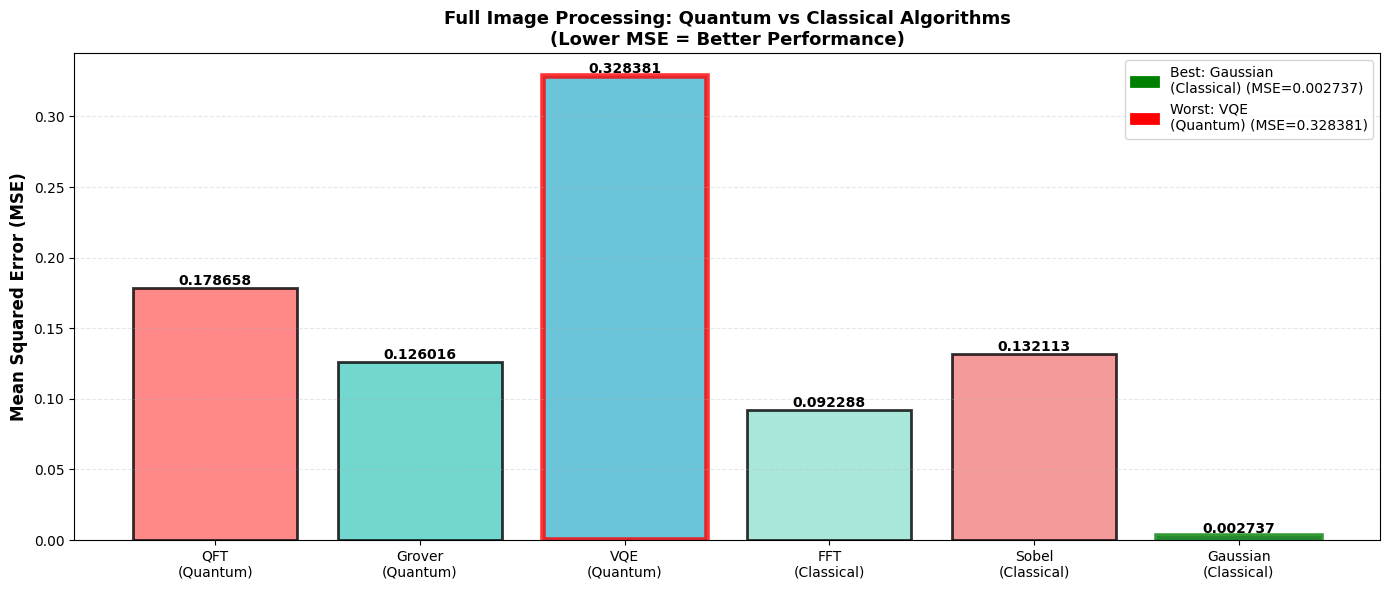


✓ BEST  PERFORMER: Gaussian (Classical) with MSE = 0.0027373459
✗ WORST PERFORMER: VQE (Quantum) with MSE = 0.3283806931


In [30]:
# Comprehensive comparison across all methods
methods = ['QFT\n(Quantum)', 'Grover\n(Quantum)', 'VQE\n(Quantum)',
           'FFT\n(Classical)', 'Sobel\n(Classical)', 'Gaussian\n(Classical)']
mse_values = [mse_qft_full, mse_grover_full, mse_vqe_full,
              mse_fft_full, mse_sobel_full, mse_gaussian_full]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#95E1D3', '#F38181', '#AA96DA']

# Find best and worst
best_idx = np.argmin(mse_values)
worst_idx = np.argmax(mse_values)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(methods, mse_values, color=colors, edgecolor='black', linewidth=2, alpha=0.8)

# Highlight best and worst
bars[best_idx].set_edgecolor('green')
bars[best_idx].set_linewidth(4)
bars[worst_idx].set_edgecolor('red')
bars[worst_idx].set_linewidth(4)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, mse_values)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.6f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Mean Squared Error (MSE)', fontsize=12, fontweight='bold')
ax.set_title('Full Image Processing: Quantum vs Classical Algorithms\n(Lower MSE = Better Performance)',
             fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', edgecolor='green', linewidth=2, label=f'Best: {methods[best_idx]} (MSE={mse_values[best_idx]:.6f})'),
                   Patch(facecolor='red', edgecolor='red', linewidth=2, label=f'Worst: {methods[worst_idx]} (MSE={mse_values[worst_idx]:.6f})')]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\n✓ BEST  PERFORMER: {methods[best_idx].replace(chr(10), ' ')} with MSE = {mse_values[best_idx]:.10f}")
print(f"✗ WORST PERFORMER: {methods[worst_idx].replace(chr(10), ' ')} with MSE = {mse_values[worst_idx]:.10f}")
